# Определение цвета автомобиля на изображении

Программа использует YOLOl11-seg для определения автомобоилей на изображении, а также метод кластеризации К-средних для определения доминирующего цвета на автомобиле.

## Подготовка

Клонируйте репозиторий, в папку с репозиторием скачайте [YOLO-11l-seg](https://github.com/ultralytics/assets/releases/download/v8.4.0/yolo11l-seg.pt). Также в папку репозитория клонируйте слеующий [репозиторий](https://huggingface.co/G1Gru/VITforCarColorClassification/tree/main), это модель для определения цвета автомобиля

Установите через pip зависимости
``` bash
pip install -r requiements.txt
```

## Загрузка и подключение пакетов
#### (может занять время)

In [2]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
import cv2
from ultralytics import YOLO
from collections import defaultdict
import numpy as np
from sklearn.cluster import KMeans
from torch import device, no_grad, cuda
from transformers import  ViTImageProcessor, ViTForImageClassification
from PIL import Image
import matplotlib.pyplot as plt

## Загрузка моделей

In [3]:
model_path = './color_detection_model/'
color_detection_processor = ViTImageProcessor.from_pretrained(model_path)
color_detection_model = ViTForImageClassification.from_pretrained(model_path)
color_detection_model.eval()
_device = device("cuda" if cuda.is_available() else "cpu")
color_detection_model.to(_device)


model = YOLO('yolo11l-seg.pt')

Loading weights: 100%|██████████| 200/200 [00:00<00:00, 609.00it/s, Materializing param=vit.layernorm.weight]                                 


## Функции определения цвета с выходом RGB и в тексте

In [4]:
def ColorRGB(img, k=5):
    pixels = img.reshape(-1, 3)
    car_pixels = pixels[np.sum(pixels, axis=1) > 0]
    if len(car_pixels) == 0:
        return [0, 0, 0]
    brightness = np.mean(car_pixels, axis=1)
    final_pixels = car_pixels[(brightness > 30) & (brightness < 235)]
    
    if len(final_pixels) == 0:
        final_pixels = car_pixels
    kmeans = KMeans(n_init=10, n_clusters=k, random_state=42)
    kmeans.fit(final_pixels)
    counts = np.bincount(kmeans.labels_)
    dominant_idx = np.argmax(counts)
    dominant_bgr = kmeans.cluster_centers_[dominant_idx]
    rgb_list = [int(x) for x in dominant_bgr[::-1]]
    
    return rgb_list

def ColorText(img):
    color_coverted = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    pil_img = Image.fromarray(color_coverted)
    inputs = color_detection_processor(images=pil_img, return_tensors="pt").to(_device)

    with no_grad():
        outputs = color_detection_model(**inputs)
    logits = outputs.logits
    predicted_class_idx = logits.argmax(-1).item()

    color_name = color_detection_model.config.id2label[predicted_class_idx]
    
    return color_name

## Применение модели YOLO 11 для определения автомобилей на изображении

In [10]:
img = cv2.imread('imgaes4.jpg')
results = model.track(img, persist=True, classes=[2, 3, 5, 7]) 

0: 448x640 9 cars, 275.3ms
Speed: 2.9ms preprocess, 275.3ms inference, 11.8ms postprocess per image at shape (1, 3, 448, 640)


## Определение цвета и вывод

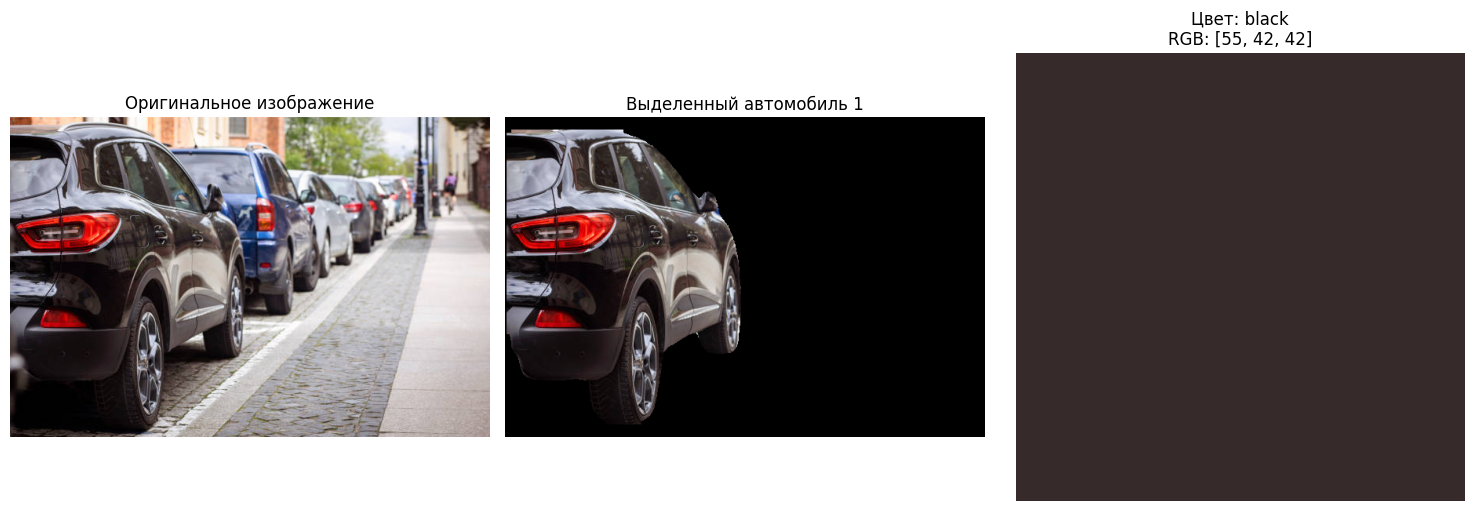

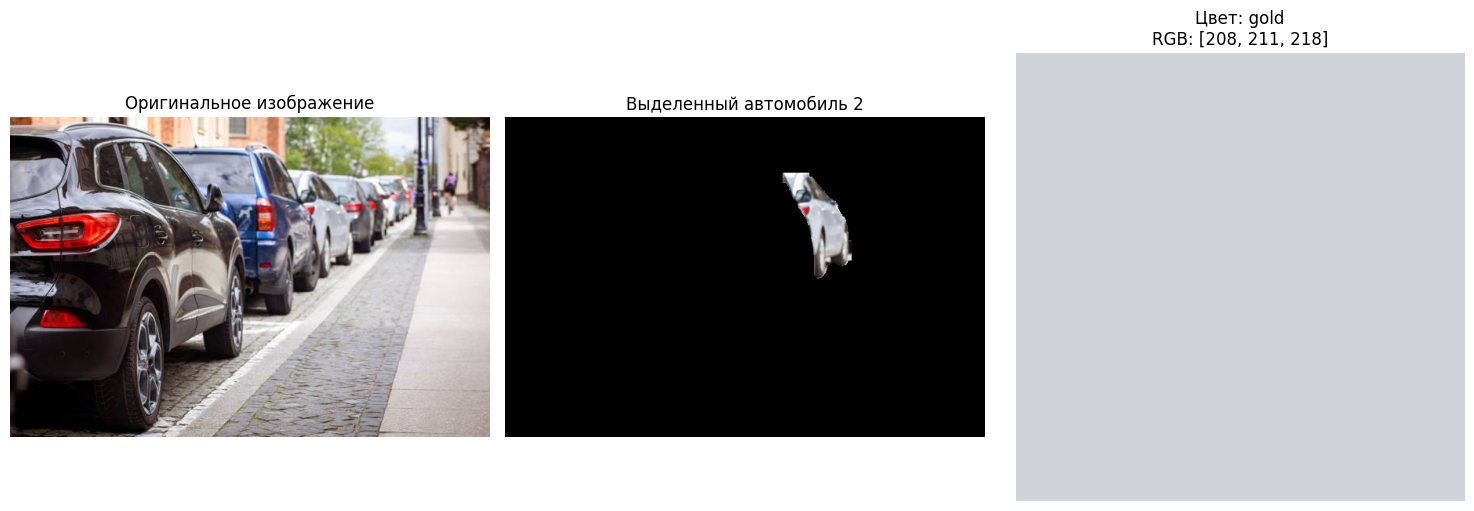

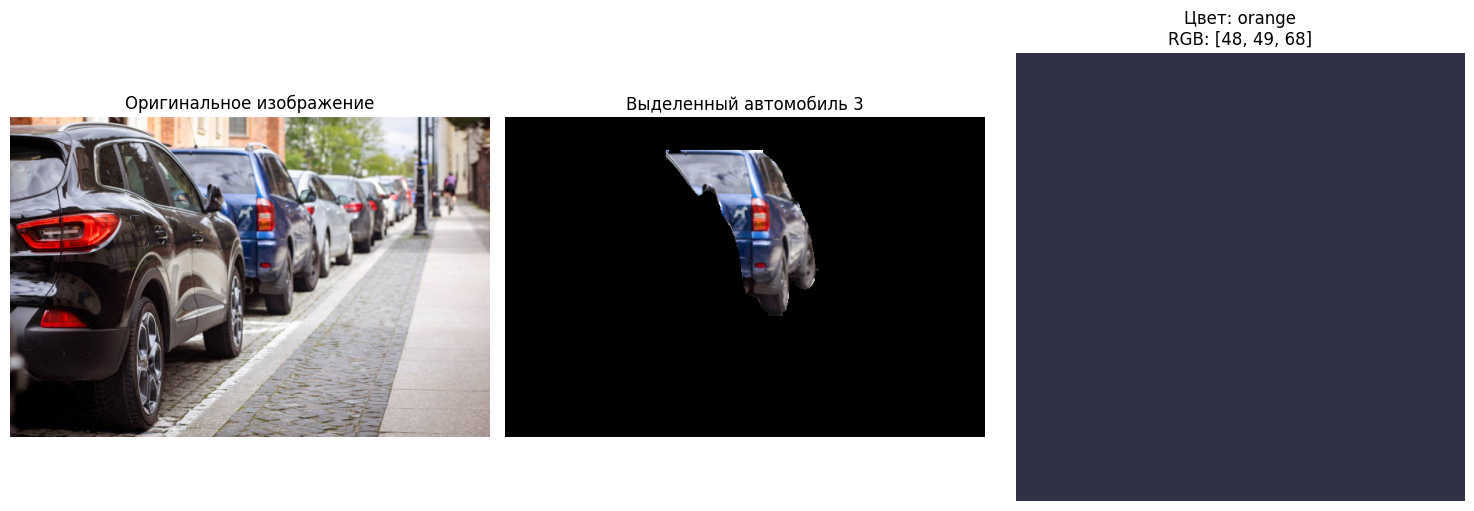

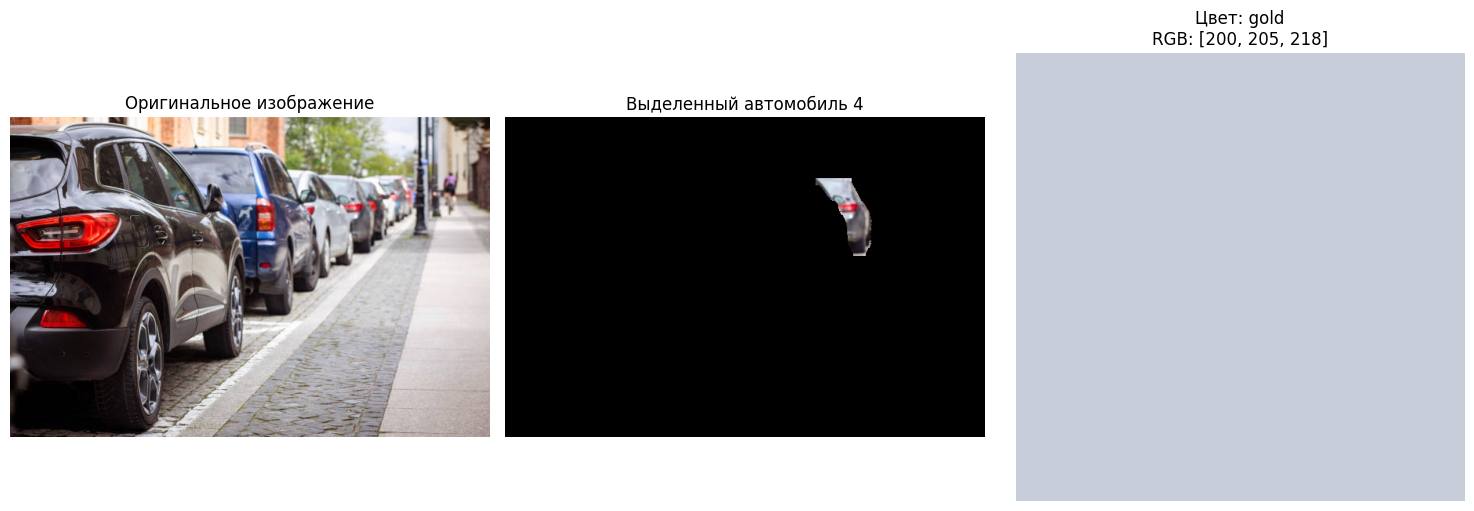

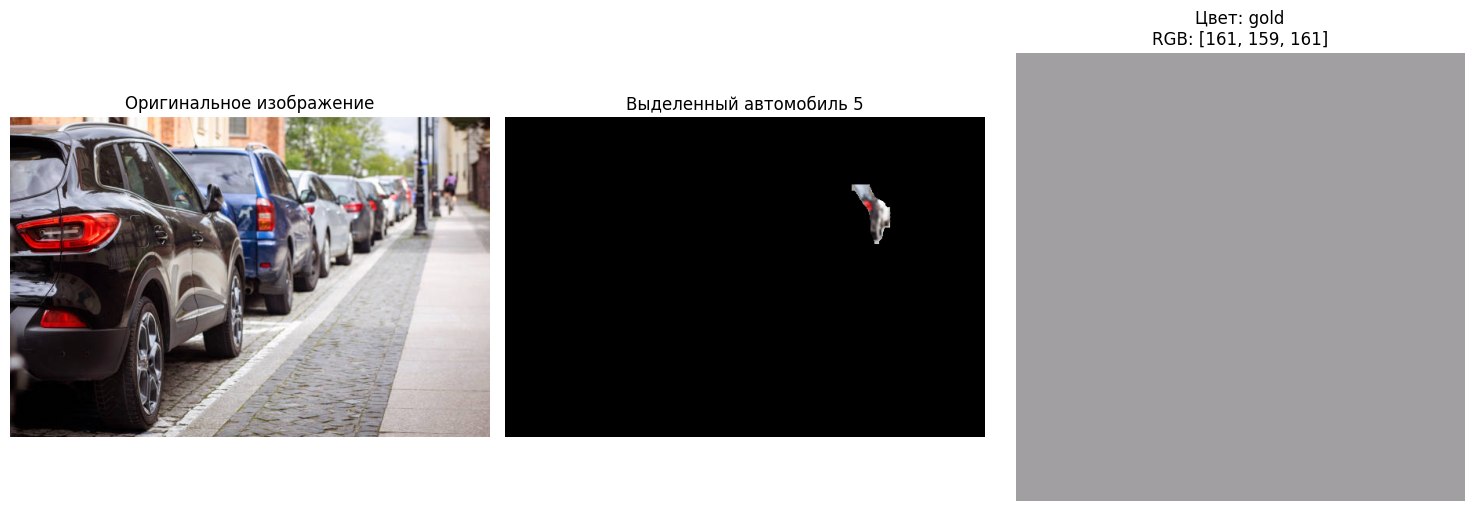

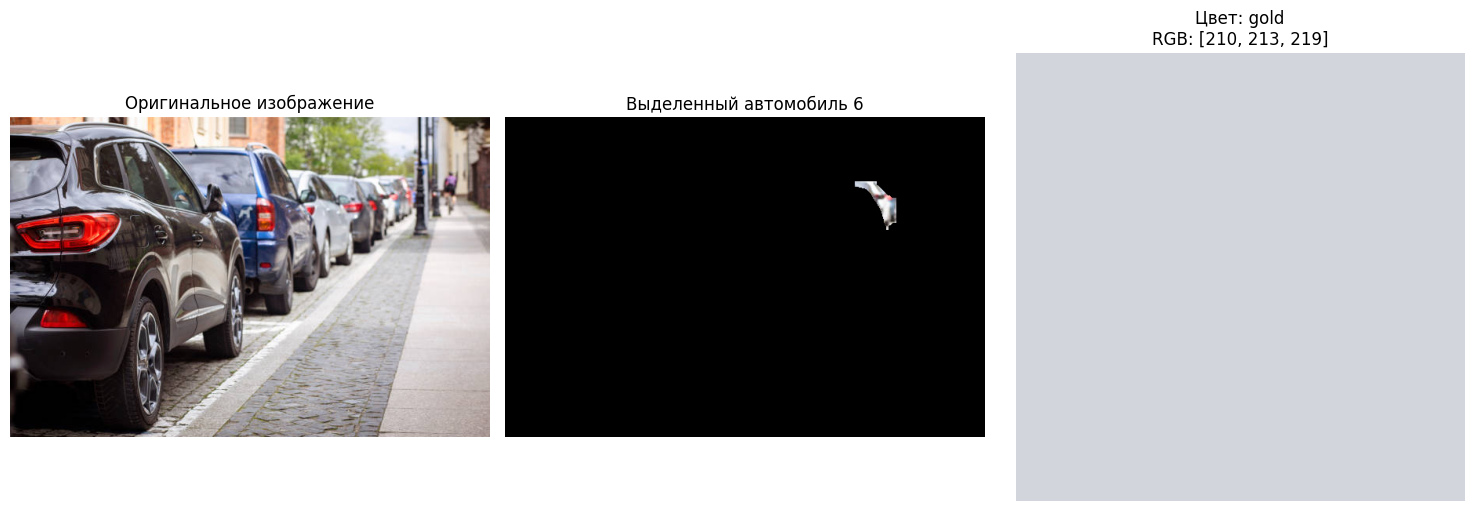

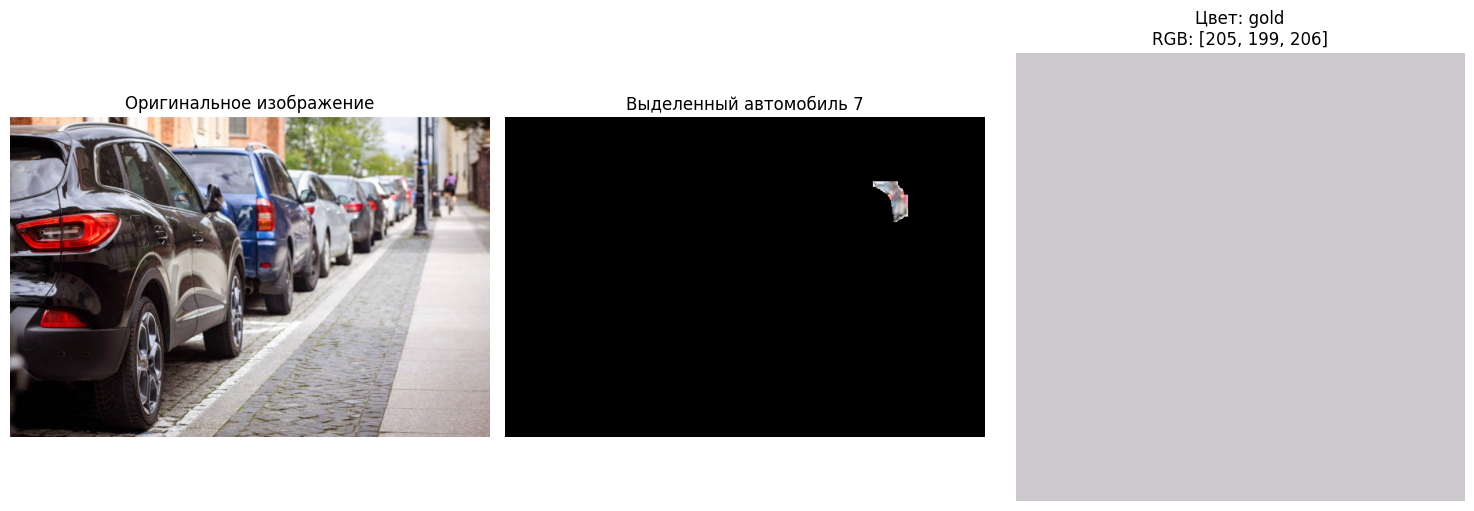

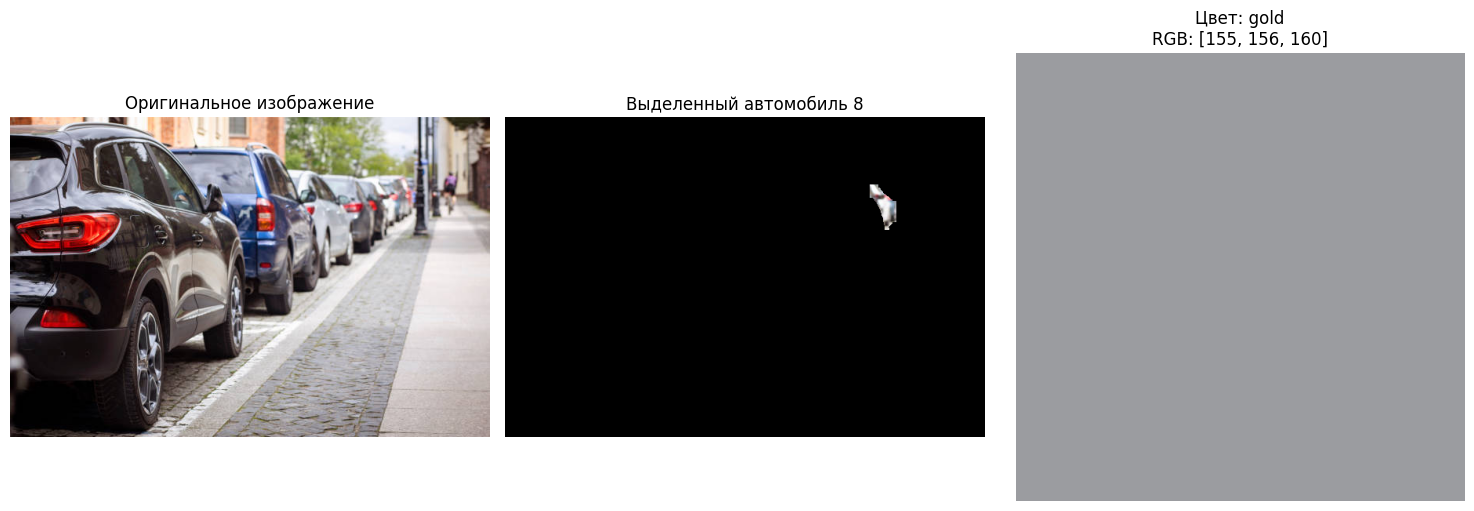

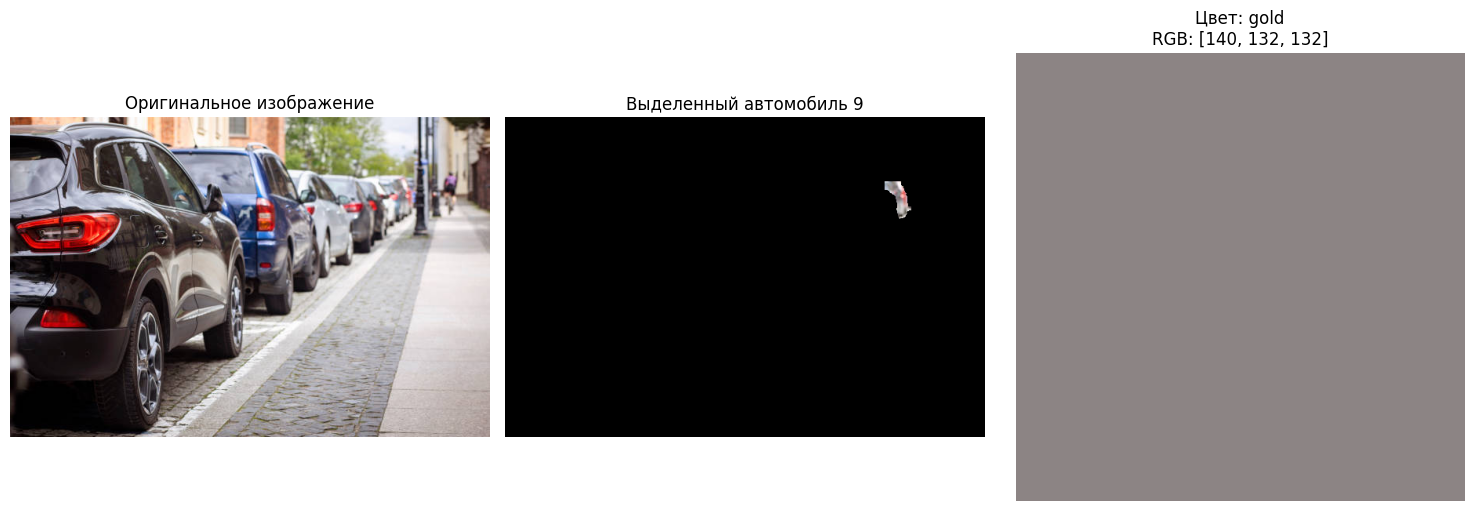

In [11]:
import matplotlib.pyplot as plt

if results[0].masks is not None:
    for i, mask_data in enumerate(results[0].masks.data):
        mask = mask_data.cpu().numpy()
        mask_res = (cv2.resize(mask, (img.shape[1], img.shape[0])) > 0).astype(np.uint8)

        isolated = cv2.bitwise_and(img, img, mask=mask_res)

        rgb_val = ColorRGB(isolated)
        name_val = ColorText(isolated)
        fig, ax = plt.subplots(1, 3, figsize=(15, 5))

        ax[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax[0].set_title("Оригинальное изображение")
        ax[0].axis('off')

        ax[1].imshow(cv2.cvtColor(isolated, cv2.COLOR_BGR2RGB))
        ax[1].set_title(f"Выделенный автомобиль {i+1}")
        ax[1].axis('off')

        color_tile = np.zeros((100, 100, 3), dtype=np.uint8)
        color_tile[:] = rgb_val
        ax[2].imshow(color_tile)
        ax[2].set_title(f"Цвет: {name_val}\nRGB: {rgb_val}")
        ax[2].axis('off')

        plt.tight_layout()
        plt.show()
else:
    print("Объекты не найдены.")